In [ ]:
import numpy as np
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath("../.."))

import utils.plot as pu

In [16]:
# module for loading some popular datasets
from sklearn import datasets

iris = datasets.load_iris()
print(type(iris))

# both x and y are numpy ndarrays
X = iris.data[:,[2,3]]
y = iris.target

print("class labels : ", np.unique(y))

<class 'sklearn.utils._bunch.Bunch'>
class labels :  [0 1 2]


In [17]:
# module for creating shuffled unbiased train test split
from sklearn.model_selection import train_test_split

# Stratify parameter= divides the training and testing data having the same proportion for each 
# label as the original dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# verification of the stratify split
print("Labels in y : ", np.bincount(y))
print("Labels in y_train : ", np.bincount(y_train))
print("Labels in y_test : ", np.bincount(y_test))


Labels in y :  [50 50 50]
Labels in y_train :  [35 35 35]
Labels in y_test :  [15 15 15]


In [18]:
# Module for feature scaling using standardization
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)

X_std = sc.transform(X)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [19]:
# Inbuilt Perceptron in sklearn 
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

y_pred = ppn.predict(X_test_std)
print(f"Misclassified Examples : {(y_pred != y_test).sum()}")


Misclassified Examples : 1


In [20]:
# calculating performance of the model
# 1. using performance metrics from sklearn.metrics module
# 2. using score method present for each classifier in sklearn

from sklearn.metrics import accuracy_score 
print(f"Accuracy score : {accuracy_score(y_test, y_pred) : .3f}")

print(f"Perceptron score : {ppn.score(X_test_std, y_test) : .3f}")


Accuracy score :  0.978
Perceptron score :  0.978


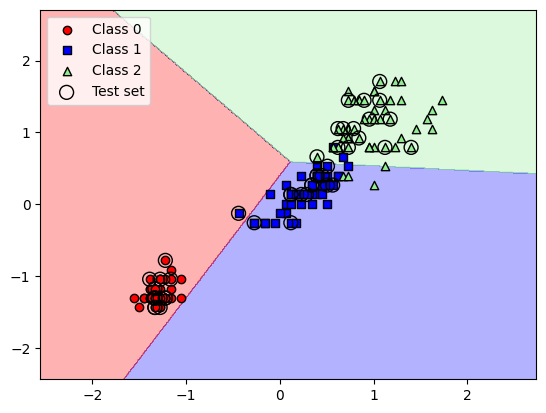

In [21]:
pu.plot_decision_regions(X=X_std, y=y, model=ppn, X_test=X_test_std, resolution=0.01)
